# Creating a Random Forest ML Model

This notebook goes through how to rapidly protype a Random Forest model with ```ml_fw```. It follows the methodology of Murphy et al. 2024 and reproduces the FISM2/Geo model. 

It doesn't do a grid search for the Random Forest parameters as it's very time consuming. It does however go through the generation of the correlation matrices (Figure 2 b and c), plotting of the case-studies (Figure 5), and the residual analysis (Figure 6)

- Add correlations

In [1]:
import os, sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics

path_dat = f'D:\\data\\SatDensities\\satdrag_database_grace_B.hdf5'
path_oos = f'D:\\data\\SatDensities\\satdrag_database_grace_CHAMP.hdf5'


In [2]:
from ml_fw import profile as pro
from ml_fw import data_io as dio
from ml_fw import ml_mod as ml
from ml_fw import inspect as insp

In [3]:
# read in data
dat = pd.read_hdf(path_dat)

In [4]:
# generate correlation matrices
# for the different datasets
fism_columns = ['225_00', '600_01', '1300_02', '2500_03', '5100_04',
            '11250_05', '18950_06', '25700_07', '30500_08', '43000_09', '59500_10',
            '72400_11', '72400_12', '85550_13', '85550_14', '85550_15', '94400_16',
            '94400_17', '94400_18', '98100_19', '100700_20', '103850_21',
            '113000_22','storm','storm phase']

geo_columns = ['Bx_GSEGSM','By_GSM', 'Bz_GSM', 
           'Vsw', 'Vx_GSE', 'Vy_GSE', 'Vz_GSE', 'Prho', 'Tp',
           'dynP', 'Esw', 'AE', 'AL', 'AU', 'SYM_H index',
           'storm', 'storm phase']

target = ['400kmDensity']

# define lambda functions so we can filter categorical data  
mp = lambda x: x['storm phase'] == 1 # correlation when storm phase column = 1, the main phase
rc = lambda x: x['storm phase'] == 2 # equals 2, the recovry phase
storm = lambda x: x['storm'] == 1 # storm times
quiet = lambda x: x['storm'] < 1 # quiet times

# create a dictionary of the lambda functions
# keys are the names of the returned correlations
# values are the evaluated lambda functions
cat = {'Quiet':quiet, 'Storm':storm,'Main':mp, 'Recovery':rc}

c:\Users\murph\miniconda3\envs\mlfw\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\murph\miniconda3\envs\mlfw\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


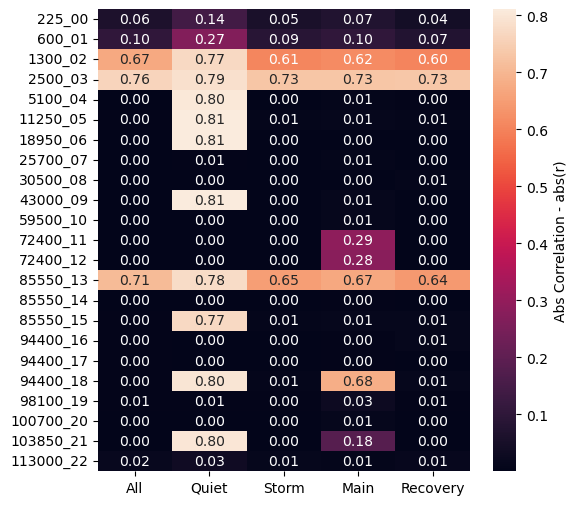

In [5]:
# calculate the correlation matrix
f_corr = pro.cor_matrix(f_dat=fism_columns, 
                    y_dat=target,
                    cor_dat=dat, cat_dat=cat, numeric_only=True)

# plot the correlation matrix
# the last two columns are used 
# for the categorical data and filtering
# we don't need them in the plot
plt.figure(figsize=(6, 6))
sns.heatmap(f_corr[:-2].abs(),annot=True, fmt='.2f', cbar_kws={'label':'Abs Correlation - abs(r)'})
plt.yticks() 
plt.show()

c:\Users\murph\miniconda3\envs\mlfw\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\murph\miniconda3\envs\mlfw\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


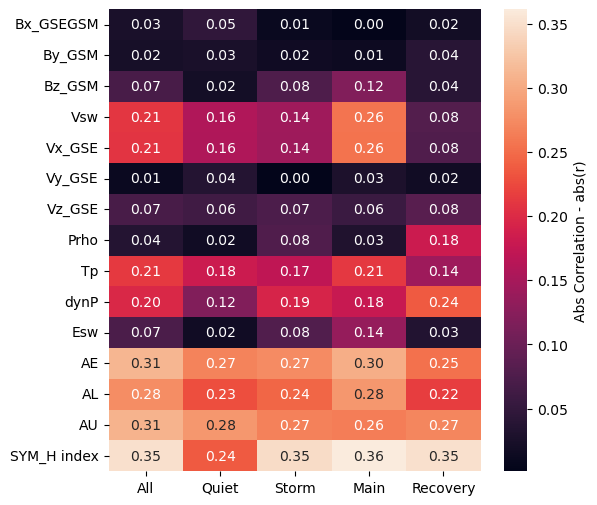

In [6]:
# calculate the correlation matrix
g_corr = pro.cor_matrix(f_dat=geo_columns, 
                    y_dat=target,
                    cor_dat=dat, cat_dat=cat, numeric_only=True)

# plot the correlation matrix
# the last two columns are used 
# for the categorical data and filtering
# we don't need them in the plot
plt.figure(figsize=(6, 6))
sns.heatmap(g_corr[:-2].abs(),annot=True, fmt='.2f', cbar_kws={'label':'Abs Correlation - abs(r)'})
plt.yticks() 
plt.show()

### Model Features and Targets

Note, saving the time and categorical columns aids in model inspection later.


In [7]:
# define the columns that we will be using in the model
# these columns correspond to those with high correlations
# identified from the above
#
# we include the time and catergorical columns as the are 
# helpful when investigating case studies
# or model performance for categorical variables (storm/storm phase)
df_cols = {
    'feat_col': ['1300_02','43000_09','85550_13','94400_18',
                  'SYM_H index','AE','SatLat'],
    'y_col': ['400kmDensity'],
    'log_col': ['1300_02', '43000_09', '85550_13', '94400_18'],
    'lt_col': ['SatMagLT'],
    't_col': ['DateTime', 'storm', 'storm phase']
    }

# define RF model parameters
# these have been determined
# from a previous hyperparameter
# search

# rnd is used for both the splitting
# of the data and the Random Forest
# so that we get consitent results
# when the notebook is ran again
rnd=17
rf_params = {
    "n_estimators": 500,
    "max_depth": None,
    "min_samples_split": 2,
    "min_samples_leaf":5,
    "warm_start":False,
    "oob_score":True,
    "random_state": rnd,
    "max_features":0.5,
    "n_jobs":10
    }

In [8]:
# drop NaN values from the columns
# we'll be using the RF
rf_cols = [y for _, val in df_cols.items() for y in val]

dat = dat.dropna(axis=0, subset=rf_cols)

# use create from data_io to generate two 
# dataframes:
# feature and time/categorical DataFrame
# target/y DataFrame
ml_f, ml_y = dio.create(dat,**df_cols)

# convert density to a more appropriate
# range to avoid errors (e.g., target too 
# small)
ml_y = ml_y*10**12 



c:\Users\murph\miniconda3\envs\mlfw\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [9]:
# delete DataFrame for space
del dat


In [10]:
# create train test splits
train_x, test_x, train_y, test_y = train_test_split(ml_f, ml_y, 
                                                        test_size=0.3, 
                                                        random_state=rnd)

# pull and drop the time columns from the x data
train_t = train_x[df_cols['t_col']]
test_t = test_x[df_cols['t_col']]

train_x = train_x.drop(columns=df_cols['t_col'])
test_x = test_x.drop(columns=df_cols['t_col'])

In [11]:
# train the random forest model
rfr = RandomForestRegressor(**rf_params)
rfr.fit(train_x, train_y.values.ravel())

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",0.5
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [12]:
# predict the y-values from the train
# data and combine into a single
# DataFrame
pred_tr = rfr.predict(train_x)

In [13]:
train_d = train_x.join([train_y,train_t], how='left')
train_d[df_cols['y_col'][0]+'_pred'] = pred_tr


### Out-of-Sample Predictions

In [14]:
# determine predictions for
# out-of-sample dataset
oos_dat = pd.read_hdf(path_oos)

oos_f, oos_y = dio.create(oos_dat,**df_cols)
oos_y = oos_y*10**12

oos_d = oos_f.join([oos_y])

oos_d[df_cols['y_col'][0]+'_pred'] = rfr.predict(oos_f.drop(columns=df_cols['t_col']))

# delete the full DataFrame for space
del oos_dat



c:\Users\murph\miniconda3\envs\mlfw\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


### Plot Case Studies

Plot geomagnetic inputs Sym-H and AE as well as observed and predicted density from the out-of-sample CHAMP dataset. 

Also include running metrics from out-of-sammple data set to investigate when the model performs well and when it could do better. 

In [15]:
# events
# quiet day 2008-05-10, 2008-05-18
# small storm, 2008-09-01, 2008-09-12
# moderate storm, 2006-04-12, 2006-04-20
# large storm, 2005-08-21, 2005-08-30

# large storm
sdate = '2005-08-21'
edate = '2005-08-30'

In [16]:
# observed and predicted data
# time column to perform the rolling calculation on
y_true = '400kmDensity'
y_pred = '400kmDensity_pred'
on = 'DateTime'

# keywords for the rolling window
# use a 90 minute centered windo
rkwargs = {'window':'90min','center':True}

# metric to calculate
met = {'MedAE':lambda y_true, y_pred: metrics.median_absolute_error(y_true, y_pred),
       'MAE':lambda y_true, y_pred: metrics.mean_absolute_error(y_true, y_pred)}

In [17]:
# calculate the running metrics using the inspect module
# its much faster if we just calculate it over the window we need
gd = (oos_d['DateTime'] >= sdate) & (oos_d['DateTime'] <= edate)
r_met = insp.rolling_met(oos_d[gd],y_true=y_true,y_pred=y_pred,on=on,
                        roll_kwargs=rkwargs, roll_metric=met)

# truncate data for faster plotting
# and because something odd is happening
# the shared axis
oos_p = oos_d[gd].copy()

Using passed metric


<Figure size 640x480 with 0 Axes>

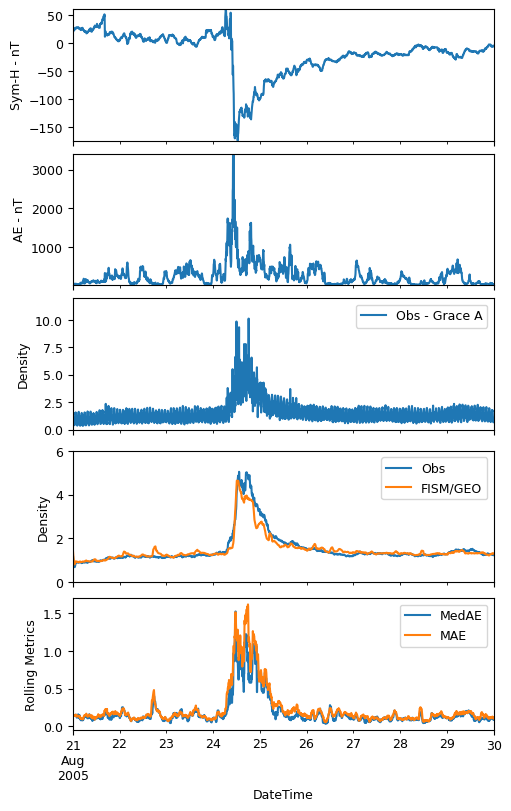

In [18]:
plt.rcParams.update({'font.size': 9})
plt.subplots_adjust(hspace=0)
fig1, ax1 = plt.subplots(5,1,figsize=(5,8),sharex=True, layout='constrained')

pos = 0
ylim = [oos_d.loc[gd,'SYM_H index'].min(),oos_d.loc[gd,'SYM_H index'].max()]
oos_p.plot(x='DateTime', y='SYM_H index', xlim=[sdate,edate], ylim=ylim, ax=ax1[pos], label='Sym-H', ylabel='Sym-H - nT', legend=False)

pos = 1
ylim = [oos_d.loc[gd,'AE'].min(),oos_d.loc[gd,'AE'].max()]
oos_p.plot(x='DateTime', y='AE', xlim=[sdate,edate], ylim=ylim, ax=ax1[pos], label='AE', ylabel='AE - nT', legend=False)

pos = 2
oos_p.plot(x='DateTime', y='400kmDensity', xlim=[sdate,edate], ylim=[0,12], ax=ax1[pos], label='Obs - Grace A', ylabel='Density', legend=True)

pos = 3
oos_p[['DateTime','400kmDensity']].rolling('90min',on='DateTime').mean().plot(x='DateTime', y='400kmDensity', xlim=[sdate,edate], ylim=[0,6], ax=ax1[pos], label='Obs', ylabel='Density', legend=False)
oos_p[['DateTime','400kmDensity_pred']].rolling('90min',on='DateTime').mean().plot(x='DateTime', y='400kmDensity_pred', xlim=[sdate,edate], ax=ax1[pos], label='FISM/GEO', ylabel='Density', legend=False)
ax1[pos].legend(bbox_to_anchor=(1.,1))

pos = 4
r_met.plot(x='DateTime', y='MedAE', ax=ax1[pos], label='MedAE', ylabel='Rolling Metrics', legend=False)
r_met.plot(x='DateTime', y='MAE', ax=ax1[pos], label='MAE', legend=False)
ax1[pos].legend(bbox_to_anchor=(1.,1))

#fig1.draw

### Residual Box and Whisker Plots

Plot box and whisker plots for the model residuals as a function of geomagnetic activity using the ```inspect``` submodule.

In [19]:
# calculate the residuals
oos_d['resid'] = oos_d['400kmDensity'] - oos_d['400kmDensity_pred']

In [20]:
# define the cols of data that we want to use for binning
# and their ranges and number of bins
x_dat = ['AE', 'SYM_H index']
x_bin = [20,21]
x_range = [[0,2000], [-200,10]]
# the y_col to derive the stats
y_dat = ['resid']

whisker = 0 # don't want whiskers
showmean = True # plot the means

In [21]:
# derive the box/whisker data for each x dat
box_dat = insp.boxplot_vx(oos_d[x_dat],oos_d[y_dat], whisker=whisker,
                           bins=x_bin,xrange=x_range)

AE
SYM_H index


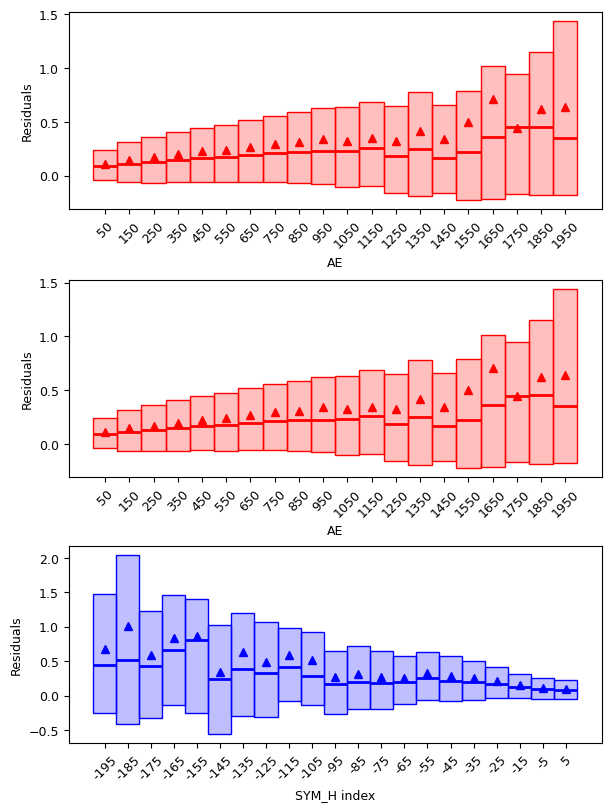

In [22]:
# plot the data
fig, ax = plt.subplots(3,1, figsize=(6,8))
fig.set_constrained_layout(True)

# boxplot_vx returns a dictionary for each of x_dat which contains 
# the required values to plot a boxplot using bxp()
# the dictionary key is the inputs DataFramed column names

# lets look at the returned dictionary for AE
ae_box = box_dat['AE'] # the AE box/whisker data
y_val = ae_box['box_stats'] # a list of dictionaries for each box/whisker instance
x_val = ae_box['x_centre'] # the center of each x bin
x_width = ae_box['x_width'] # the width of each x bin

# lets define some colors, alpha values (transparencies) and other properties to
# make the plot pretty 

cc = [1,0,0] # red box plot
bx_a = 0.25 # transparency level (alpha) for box
ln_a = 1.0 # transparency level for lines
ln_w = 2.0 # line width

b1 = ax[0].bxp(y_val, positions=x_val, widths=x_width, 
                  patch_artist=True, showmeans=showmean, 
                  shownotches=False, showcaps=False, 
                  boxprops={'ec':cc+[ln_a], 'fc':cc+[bx_a]}, # artist properties for boxes
                  medianprops={'c':cc, 'lw':ln_w}, # artist properties for medians
                  meanprops={'mec':cc, 'mfc':cc}) # artist propoerties for means

# lets fix the x-axis a bit and label everything
ax[0].set_xticks(x_val,x_val.astype(int).astype(str),rotation=45)
ax[0].set_ylabel('Residuals')
ax[0].set_xlabel('AE')

# lets do the same thing but loop through the returned box_dat
# to create a box/whisker plot for each returned key (x_dat)
# loop through the dictionary to plot all box_plots
pc = [cc, [0,0,1]]
for (key, value), ap, bc, in zip(box_dat.items(), ax[1:], pc):
    print(key)
    plt_box = box_dat[key]
    y_val = plt_box['box_stats']
    x_val = plt_box['x_centre']
    x_width = plt_box['x_width']
    
    b = ap.bxp(y_val, positions=x_val, widths=x_width, 
                      patch_artist=True, showmeans=showmean, 
                      shownotches=False, showcaps=False, 
                      boxprops={'ec':bc+[ln_a], 'fc':bc+[bx_a]},
                      medianprops={'c':bc, 'lw':ln_w}, 
                      meanprops={'mec':bc, 'mfc':bc})
    ap.set_xticks(x_val,x_val.astype(int).astype(str),rotation=45)
    ap.set_ylabel('Residuals')
    ap.set_xlabel(key)